In [1177]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

In [1178]:
shape_path = r'D:\A_joyCODE\DEV_LIN\ampExt\CSSyl\Isomap\isomapCmdsCSSylk10d3distmin_keepOut.txt'
shapeU_1_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig40_minDist0.2.txt'
shapeU_2_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig30_minDist0.2.txt'
shapeU_3_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig5_minDist0.2.txt'
shapeU_4_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig30_minDist0.2.txt'
#shapeU_4_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim3_neig5_minDist0.2.txt'
try:
    shape = pd.read_csv(shape_path, index_col=0, header=0)
    print(shape.head())
    shapeU_1 = pd.read_csv(shapeU_1_path, index_col=0, header=0)
    shapeU_2 = pd.read_csv(shapeU_2_path, index_col=0, header=0)
    shapeU_3 = pd.read_csv(shapeU_3_path, index_col=0, header=0)
    shapeU_4 = pd.read_csv(shapeU_4_path, index_col=0, header=0)

    shapeU_1.rename(columns={'UMAP1': 'UMAP1_U1'}, inplace=True)
    shapeU_2.rename(columns={'UMAP1': 'UMAP1_U2'}, inplace=True)
    shapeU_3.rename(columns={'UMAP1': 'UMAP1_U3', 'UMAP2': 'UMAP2_U3'}, inplace=True)
    shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4'}, inplace=True)
    #shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4','UMAP3': 'UMAP3_U4'}, inplace=True)
except FileNotFoundError as e:
    print(f"Error: {e}")

#shape_joined = shape.join(shapeU)
shape_joined = shape.join([shapeU_1, shapeU_2, shapeU_3, shapeU_4])
shape = shape_joined
print(shape.head())

                     1         2         3
subjName                                  
LPC24_struct -3.129764 -0.129110 -1.895557
LPC05_struct -3.857513 -3.494893  1.386982
LPA30_struct  4.102761  1.443144 -0.599581
LPC21_struct -1.398569 -1.033002  0.397889
LPA32_struct -3.843092  2.432006  1.754709
                     1         2         3  UMAP1_U1   UMAP1_U2   UMAP1_U3  \
subjName                                                                     
LPC24_struct -3.129764 -0.129110 -1.895557 -3.787216   5.504291   6.693084   
LPC05_struct -3.857513 -3.494893  1.386982 -2.350594   3.216777   8.552155   
LPA30_struct  4.102761  1.443144 -0.599581  0.977927  10.334188  10.185749   
LPC21_struct -1.398569 -1.033002  0.397889 -1.830144   3.542171   8.922938   
LPA32_struct -3.843092  2.432006  1.754709 -5.498603   6.520588   7.043594   

              UMAP2_U3  UMAP1_U4  UMAP2_U4  
subjName                                    
LPC24_struct  6.385966  0.732907  4.531726  
LPC05_struct  7.3

In [1179]:
amp_info_path = r'D:\B_projWIP\proj_amputee\amputee_INFO_result\allinfoAmputeeJoy.csv'
function_path = r'D:\B_projWIP\proj_amputee\amputee_INFO_result\Functional_plasticity.csv'
try:
    shape_info = pd.read_csv(amp_info_path, index_col=0, header=0)
    print(shape_info.head())
    function_info = pd.read_csv(function_path,index_col=0, header=0)
    print(function_info.head())
except FileNotFoundError as e:
    print(f"Error: {e}")
# set subjID as index for function_info
function_info_reset = function_info.reset_index()
function_info_reset.set_index('subjID', inplace=True)
function_info = function_info_reset
print(function_info.head())

       Gender  AgeScan  AgeLimbLoss Group AmpSide DominantHand
SubjID                                                        
PA01        M       57         20.0   AMP       L          NaN
PA02        F       49          0.0  CONG       L          NaN
PA03        M       59         40.0   AMP       L          NaN
PA04        F       52          0.0  CONG       R          NaN
PA05        M       58         27.0   AMP       L          NaN
      subjID  gender  amp.side  birthyear  Prosthesisusage  Stumpusage  \
study                                                                    
2       MA03       0         1       1980             0.56        0.56   
2       MA05       1         0       1986             0.43        0.17   
2       MA08       0         0       1957             0.54        0.41   
2       MA12       1         0       1963             0.63        0.06   
2       MA14       0         0       1983             0.11        0.07   

       amputatio level  Cos  Fun  Myo  m

In [1180]:
print(len(shape_info))
print(len(function_info))

65
24


In [1181]:
# Double shape_info to account for the two hemisphere
shape_info_L = shape_info.copy()
shape_info_flip_R = shape_info.copy()
# Append 'L' to the index of the first copy
shape_info_L.index = 'L' + shape_info_L.index
# Append 'flip_R' to the index of the second copy
shape_info_flip_R.index = 'flip-R' + shape_info_flip_R.index
# Compose the new info df with the new index
shape_info_LR_combined = pd.concat([shape_info_L, shape_info_flip_R])
#print(shape_info_LR_combined)

# Do the same for function_info
function_info_L = function_info.copy()
function_info_flip_R = function_info.copy()
function_info_L.index = 'L' + function_info_L.index
function_info_flip_R.index = 'flip-R' + function_info_flip_R.index
function_info_LR_combined = pd.concat([function_info_L, function_info_flip_R])
print(function_info_LR_combined)

            study  gender  amp.side  birthyear  Prosthesisusage  Stumpusage  \
subjID                                                                        
LMA03           2       0         1       1980             0.56        0.56   
LMA05           2       1         0       1986             0.43        0.17   
LMA08           2       0         0       1957             0.54        0.41   
LMA12           2       1         0       1963             0.63        0.06   
LMA14           2       0         0       1983             0.11        0.07   
LMA26           2       0         0       1971             0.72        0.30   
LMA28           2       0         1       1980             0.15        0.15   
LMA30           2       1         0       1964             0.63        0.35   
LMA34           2       1         1       1952             0.37        0.35   
LPA02           1       1         0       1965             0.46        0.52   
LPA04           1       1         1       1962      

In [1182]:
def remove_postfix(index_name):
    return index_name.split('_')[0]

# Apply the function to the DataFrame index
shape['index_modified'] = shape.index.map(remove_postfix)

shape_indexed = shape.set_index('index_modified') 
print("\nDataFrame with Modified Index Column:")
print(shape_indexed)


DataFrame with Modified Index Column:
                       1         2         3  UMAP1_U1   UMAP1_U2   UMAP1_U3  \
index_modified                                                                 
LPC24          -3.129764 -0.129110 -1.895557 -3.787216   5.504291   6.693084   
LPC05          -3.857513 -3.494893  1.386982 -2.350594   3.216777   8.552155   
LPA30           4.102761  1.443144 -0.599581  0.977927  10.334188  10.185749   
LPC21          -1.398569 -1.033002  0.397889 -1.830144   3.542171   8.922938   
LPA32          -3.843092  2.432006  1.754709 -5.498603   6.520588   7.043594   
...                  ...       ...       ...       ...        ...        ...   
flip-RPC02     -2.283779  0.827991  2.133399 -1.617257   4.403270   8.831032   
flip-RPC15     -3.797792 -0.618864  0.383333 -4.444939   3.724389   6.107856   
flip-RPA13      0.995838  7.773048 -4.150236 -3.039818   5.893856   6.919127   
flip-RPC17     -0.688494  5.321493 -1.216060 -3.582152   6.693503   7.025908   
f

In [1183]:
# Form new info df with shape info
desired_columns = ['1', '2', '3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 
#desired_columns = ['1', '2', '3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4','UMAP3_U4'] 
joined_info_shape = pd.concat([shape_info_LR_combined, shape_indexed[desired_columns]], axis=1)
#print(joined_info_shape)

In [1184]:
def classify_index(index_name):
  """Classifies the index name with 'L' for 'l' and 'R' for 'f'."""
  if index_name.startswith('L'):
    return 'L'
  elif index_name.startswith('f'):
    return 'R'
  else:
    # Handle cases where the index doesn't start with 'l' or 'f' (optional)
    return None  # Or any other default value

# Add a column 'side' for the hemisphere of shape
joined_info_shape['side'] = joined_info_shape.index.map(classify_index)

column_mapping = {'1': 'iso1', '2': 'iso2', '3': 'iso3'}
# Rename the columns
joined_info_shape.rename(columns=column_mapping, inplace=True)

# Define a function to determine 'contraAmpSide'
def get_contra_amp_side(amp_side):
    if amp_side == 'L':
        return 'R'
    elif amp_side == 'R':
        return 'L'
    else:
        return 'none'
# Apply the function to create the new column
joined_info_shape['contraAmpSide'] = joined_info_shape['AmpSide'].apply(get_contra_amp_side)

print(joined_info_shape)

           Gender  AgeScan  AgeLimbLoss Group AmpSide DominantHand      iso1  \
LPA01           M       57         20.0   AMP       L          NaN  3.773911   
LPA02           F       49          0.0  CONG       L          NaN  2.264325   
LPA03           M       59         40.0   AMP       L          NaN  6.912057   
LPA04           F       52          0.0  CONG       R          NaN  2.580672   
LPA05           M       58         27.0   AMP       L          NaN  0.631514   
...           ...      ...          ...   ...     ...          ...       ...   
flip-RMA14      M       32          0.0  CONG       L          NaN  5.226172   
flip-RMA26      M       44          0.0  CONG       L          NaN  3.947511   
flip-RMA28      M       35          0.0  CONG       R          NaN  1.472121   
flip-RMA30      F       51          0.0  CONG       L          NaN -3.488052   
flip-RMA34      F       63          0.0  CONG       R          NaN  1.701541   

                iso2      iso3  UMAP1_U

In [1185]:
# Form new function info
joined_info_function = joined_info_shape.join(function_info_LR_combined, how='inner')
print(joined_info_function.head)
print(len(joined_info_function))
print(joined_info_function.columns)

<bound method NDFrame.head of            Gender  AgeScan  AgeLimbLoss Group AmpSide DominantHand      iso1  \
LPA02           F       49          0.0  CONG       L          NaN  2.264325   
LPA04           F       52          0.0  CONG       R          NaN  2.580672   
LPA07           M       52          0.0  CONG       L          NaN -2.022189   
LPA10           F       25          0.0  CONG       R          NaN  3.319457   
LPA14           F       28          0.0  CONG       L          NaN  5.538845   
LPA16           M       38          0.0  CONG       L          NaN -1.300998   
LPA18           F       27          0.0  CONG       L          NaN  0.847799   
LPA20           M       60          0.0  CONG       L          NaN  1.565533   
LPA21           F       34          0.0  CONG       R          NaN  3.084241   
LPA22           F       36          0.0  CONG       R          NaN  6.178370   
LPA24           F       41          0.0  CONG       L          NaN  0.473974   
LPA27     

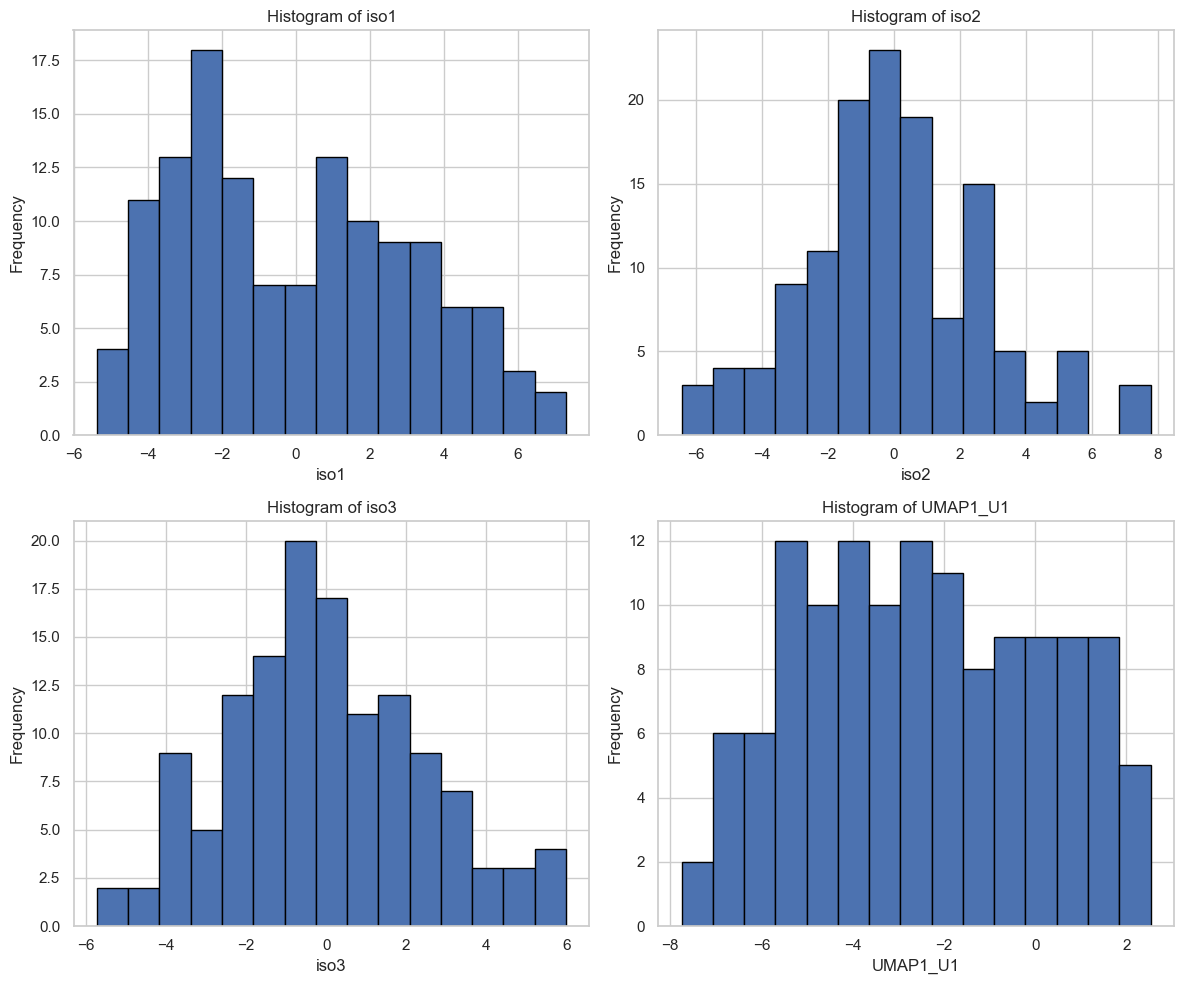

In [1186]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the histogram for 'iso1'
axs[0, 0].hist(joined_info_shape['iso1'], bins=15, edgecolor='black')
axs[0, 0].set_title('Histogram of iso1')
axs[0, 0].set_xlabel('iso1')
axs[0, 0].set_ylabel('Frequency')

# Plot the histogram for 'iso2'
axs[0, 1].hist(joined_info_shape['iso2'], bins=15, edgecolor='black')
axs[0, 1].set_title('Histogram of iso2')
axs[0, 1].set_xlabel('iso2')
axs[0, 1].set_ylabel('Frequency')

# Plot the histogram for 'iso3'
axs[1, 0].hist(joined_info_shape['iso3'], bins=15, edgecolor='black')
axs[1, 0].set_title('Histogram of iso3')
axs[1, 0].set_xlabel('iso3')
axs[1, 0].set_ylabel('Frequency')

# Plot the histogram for 'Umap'
axs[1, 1].hist(joined_info_shape['UMAP1_U1'], bins=15, edgecolor='black')
axs[1, 1].set_title('Histogram of UMAP1_U1')
axs[1, 1].set_xlabel('UMAP1_U1')
axs[1, 1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

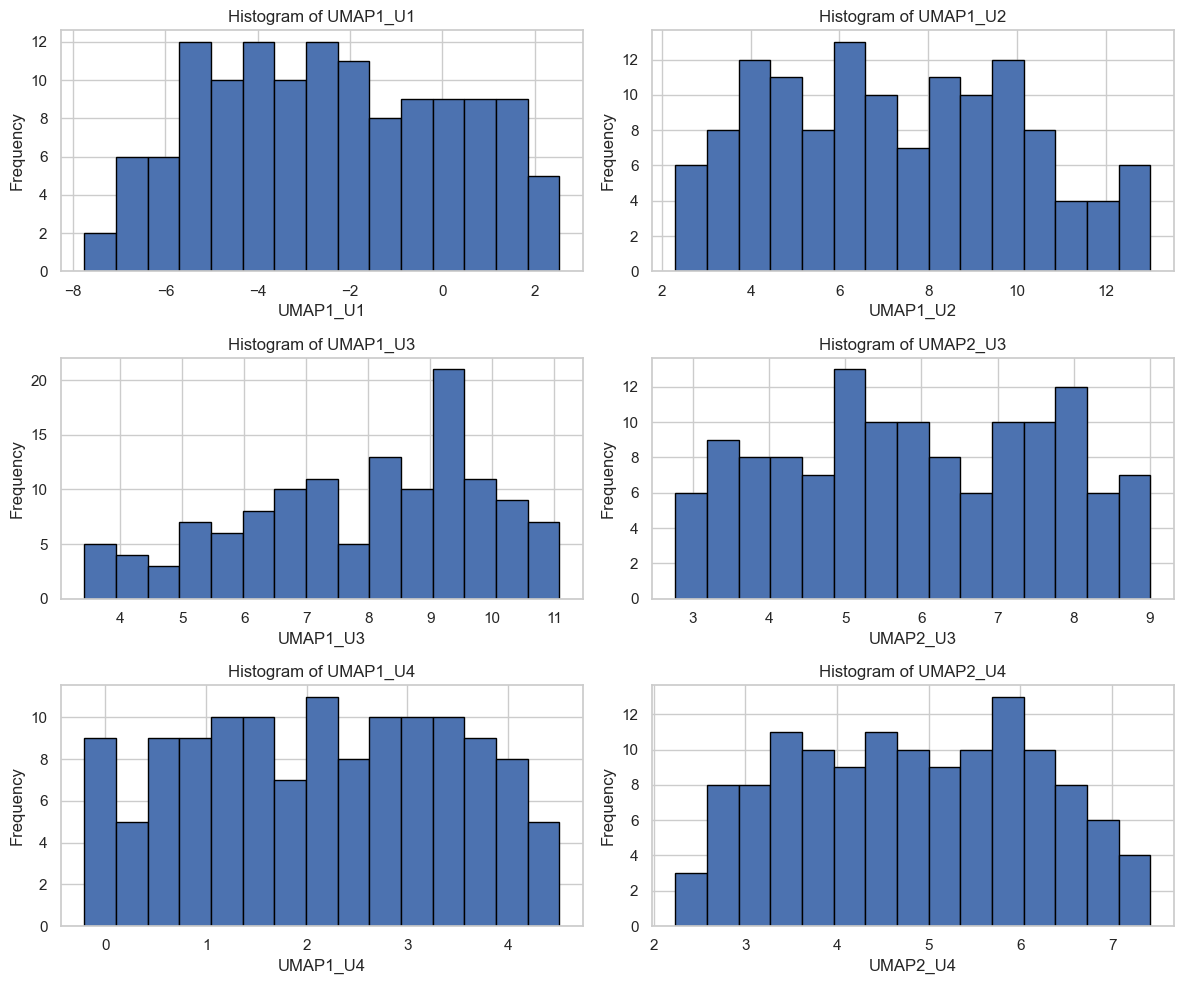

In [1187]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

# Plot the histogram for 'UMAP1_U1'
axs[0, 0].hist(joined_info_shape['UMAP1_U1'], bins=15, edgecolor='black')
axs[0, 0].set_title('Histogram of UMAP1_U1')
axs[0, 0].set_xlabel('UMAP1_U1')
axs[0, 0].set_ylabel('Frequency')
# Plot the histogram for 'iso2'
axs[0, 1].hist(joined_info_shape['UMAP1_U2'], bins=15, edgecolor='black')
axs[0, 1].set_title('Histogram of UMAP1_U2')
axs[0, 1].set_xlabel('UMAP1_U2')
axs[0, 1].set_ylabel('Frequency')

# Plot the histogram for 'UMAP1_U3'
axs[1, 0].hist(joined_info_shape['UMAP1_U3'], bins=15, edgecolor='black')
axs[1, 0].set_title('Histogram of UMAP1_U3')
axs[1, 0].set_xlabel('UMAP1_U3')
axs[1, 0].set_ylabel('Frequency')
# Plot the histogram for 'UMAP2_U3'
axs[1, 1].hist(joined_info_shape['UMAP2_U3'], bins=15, edgecolor='black')
axs[1, 1].set_title('Histogram of UMAP2_U3')
axs[1, 1].set_xlabel('UMAP2_U3')
axs[1, 1].set_ylabel('Frequency')

# Plot the histogram for 'UMAP1_U4'
axs[2, 0].hist(joined_info_shape['UMAP1_U4'], bins=15, edgecolor='black')
axs[2, 0].set_title('Histogram of UMAP1_U4')
axs[2, 0].set_xlabel('UMAP1_U4')
axs[2, 0].set_ylabel('Frequency')
# Plot the histogram for 'UMAP2_U4'
axs[2, 1].hist(joined_info_shape['UMAP2_U4'], bins=15, edgecolor='black')
axs[2, 1].set_title('Histogram of UMAP2_U4')
axs[2, 1].set_xlabel('UMAP2_U4')
axs[2, 1].set_ylabel('Frequency')
# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

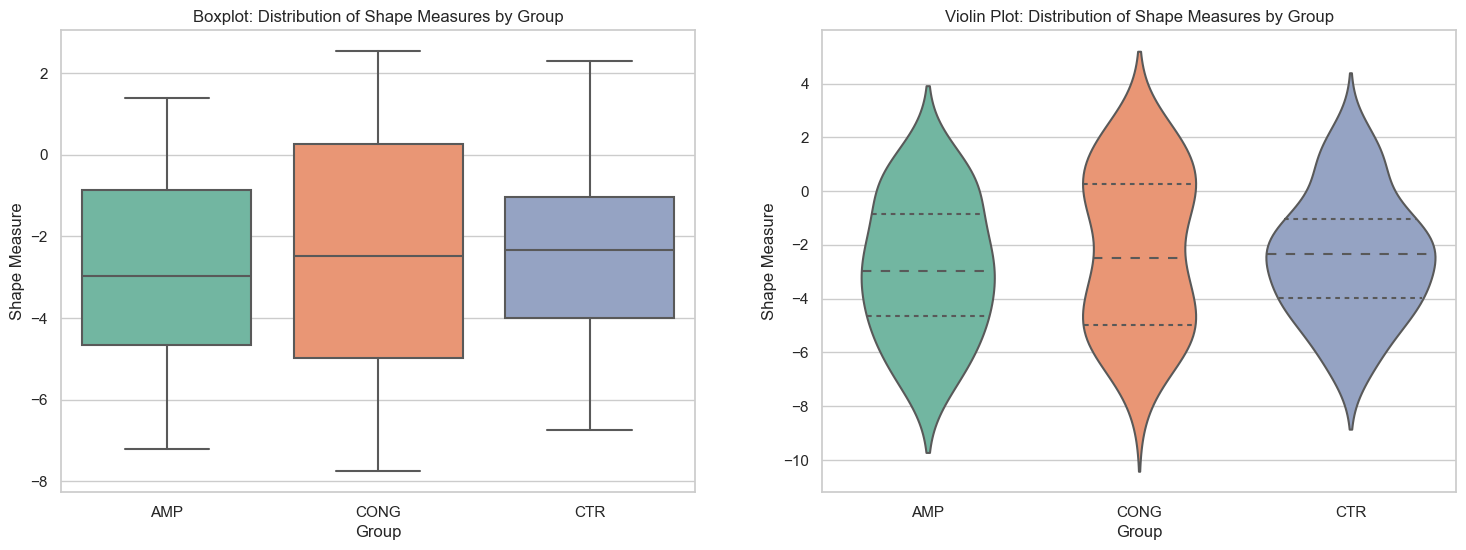

In [1188]:
# Set the style of the visualization
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot
sns.boxplot(x='Group', y='UMAP1_U1', data=joined_info_shape, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Distribution of Shape Measures by Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Shape Measure')
# Violin Plot
sns.violinplot(x='Group', y='UMAP1_U1', data=joined_info_shape, palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot: Distribution of Shape Measures by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Shape Measure')

# Show the plot
plt.show()

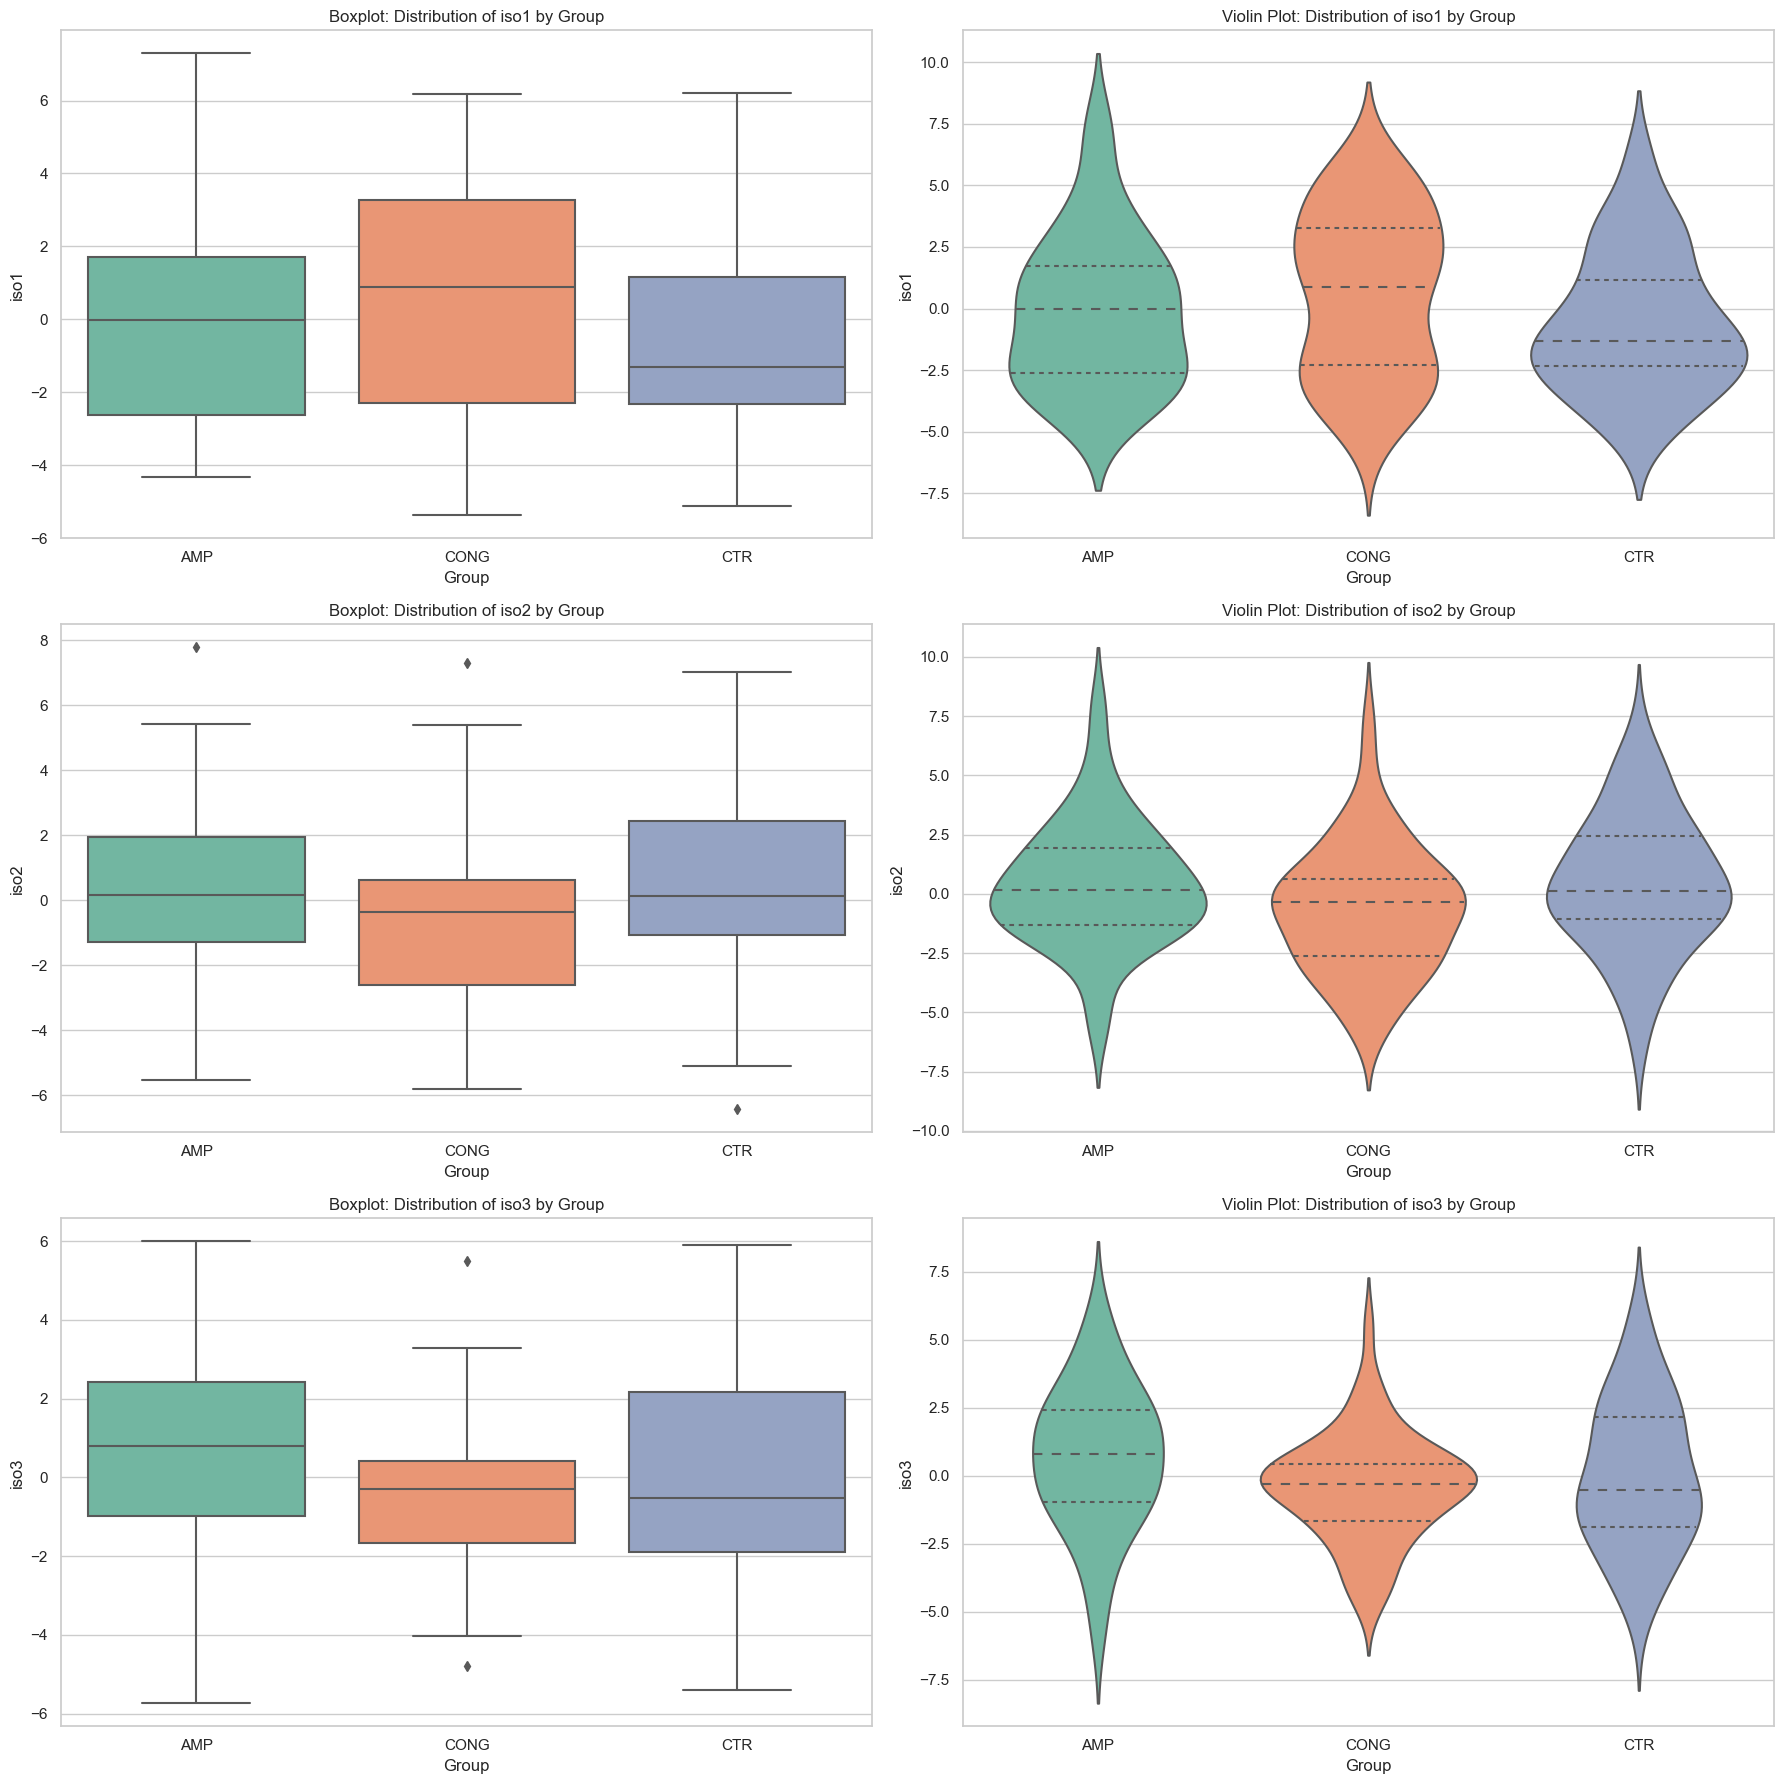

In [1189]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'iso2', 'iso3']

# Loop through the shape measures and create plots
for i, shape in enumerate(shape_measures):
    # Boxplot
    sns.boxplot(x='Group', y=shape, data=joined_info_shape, palette='Set2', ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)

    # Violin Plot
    sns.violinplot(x='Group', y=shape, data=joined_info_shape, palette='Set2', inner='quartile', ax=axes[i, 1])
    axes[i, 1].set_title(f'Violin Plot: Distribution of {shape} by Group')
    axes[i, 1].set_xlabel('Group')
    axes[i, 1].set_ylabel(shape)

# Adjust layout
plt.tight_layout()
plt.show()

In [1190]:
# Multiple factor: ols_ordinary least squares regression, then ANOVA (for Normal distribution)
model = ols('iso1 ~ C(Group) + C(side) + C(Gender)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
print()
model = ols('UMAP1_U1 ~ C(Group) + C(side) + C(Gender)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
print()


                sum_sq     df         F    PR(>F)
C(Group)     37.370227    2.0  1.981642  0.142150
C(side)      10.479953    1.0  1.111447  0.293801
C(Gender)    21.604100    1.0  2.291214  0.132633
Residual   1178.638338  125.0       NaN       NaN

               sum_sq     df         F    PR(>F)
C(Group)    14.564676    2.0  1.124983  0.327923
C(side)     36.894920    1.0  5.699563  0.018467
C(Gender)   14.163193    1.0  2.187944  0.141611
Residual   809.161183  125.0       NaN       NaN



In [1191]:
# ols_ordinary least squares regression, then ANOVA (for Normal distribution)
model = ols('iso1 ~ C(Group)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
model = ols('iso2 ~ C(Group)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
model = ols('iso3 ~ C(Group)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
model = ols('UMAP1_U1 ~ C(Group)', data=joined_info_shape).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

print()
# Multiple factor, Kruskal-Wallis
grouped = joined_info_shape.groupby(['Group', 'Gender', 'side'])['iso3'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
print()
grouped = joined_info_shape.groupby(['Group', 'Gender', 'side'])['UMAP1_U1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby(['Group', 'Gender'])['UMAP1_U1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby(['Group', 'side'])['UMAP1_U1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
print()

# Perform the Kruskal-Wallis test: non-noraml distribution
grouped = joined_info_shape.groupby('Group')['iso1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['iso2'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['iso3'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP1_U1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')

               sum_sq     df        F    PR(>F)
C(Group)    33.283814    2.0  1.74567  0.178689
Residual  1210.722391  127.0      NaN       NaN
              sum_sq     df         F   PR(>F)
C(Group)   36.677485    2.0  2.430123  0.09211
Residual  958.396209  127.0       NaN      NaN
              sum_sq     df         F    PR(>F)
C(Group)   22.471842    2.0  1.902001  0.153497
Residual  750.242531  127.0       NaN       NaN
              sum_sq     df         F    PR(>F)
C(Group)    8.496606    2.0  0.627206  0.535728
Residual  860.219296  127.0       NaN       NaN

Kruskal-Wallis H-test statistic: 28.89884366954243
p-value: 0.002353440976009928

Kruskal-Wallis H-test statistic: 11.524174533628468
p-value: 0.40044968499661654
Kruskal-Wallis H-test statistic: 4.103105379646763
p-value: 0.5346689219814257
Kruskal-Wallis H-test statistic: 7.741605402231357
p-value: 0.17106299634371136

Kruskal-Wallis H-test statistic: 2.96716617733415
p-value: 0.2268235018846538
Kruskal-Wallis H-test sta

In [1192]:
# Perform the Kruskal-Wallis test
grouped = joined_info_shape.groupby('Group')['UMAP1_U1'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP1_U2'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP1_U3'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP2_U3'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP1_U4'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
grouped = joined_info_shape.groupby('Group')['UMAP2_U4'].apply(list)
stat, p_value = kruskal(*grouped)
print(f'Kruskal-Wallis H-test statistic: {stat}')
print(f'p-value: {p_value}')
#grouped = joined_info_shape.groupby('Group')['UMAP3_U4'].apply(list)
#stat, p_value = kruskal(*grouped)
#print(f'Kruskal-Wallis H-test statistic: {stat}')
#print(f'p-value: {p_value}')

Kruskal-Wallis H-test statistic: 1.0840452143277162
p-value: 0.5815707727747651
Kruskal-Wallis H-test statistic: 10.704513505578404
p-value: 0.004737447678317474
Kruskal-Wallis H-test statistic: 0.09679242513215058
p-value: 0.9527562182976007
Kruskal-Wallis H-test statistic: 3.5740091015854887
p-value: 0.16746104016646934
Kruskal-Wallis H-test statistic: 0.04979213153262663
p-value: 0.9754112853846362
Kruskal-Wallis H-test statistic: 11.631646506165623
p-value: 0.0029800260017518346


In [1193]:
#grouped_data = df.groupby('classification')['shape_measure'].describe()
grouped_data = joined_info_shape.groupby('Group')['iso1'].describe()
print(grouped_data)
grouped_iso1 = joined_info_shape.groupby('Group')['iso1']
group1_iso1 = grouped_iso1.get_group('AMP')  # Access data for group 1
group2_iso1 = grouped_iso1.get_group('CONG')  # Access data for group 2
group3_iso1 = grouped_iso1.get_group('CTR')  # Access data for group 3

# Check if all groups have data (optional)
if len(group1_iso1) == 0 or len(group2_iso1) == 0 or len(group3_iso1) == 0:
  print("Warning: Some groups might be missing data. Consider handling missing data before ANOVA.")

# Assuming data is normally distributed
# Perform ANOVA test on the group-wise data
f_statistic, p_value = stats.f_oneway(group1_iso1, group2_iso1, group3_iso1)
print(f"F-statistic: {f_statistic}")
print(f"p-value: {p_value}")

# if data not normally distributed
h_statistic, p_value = stats.kruskal(group1_iso1, group2_iso1, group3_iso1)
print(f"H-statistic: {h_statistic}")
print(f"p-value: {p_value}")



       count      mean       std       min       25%       50%       75%  \
Group                                                                      
AMP     32.0 -0.095358  3.066952 -4.311644 -2.631660 -0.026300  1.710965   
CONG    50.0  0.598821  3.302154 -5.370157 -2.304416  0.893281  3.260653   
CTR     48.0 -0.560200  2.861422 -5.109851 -2.330022 -1.300679  1.170921   

            max  
Group            
AMP    7.290825  
CONG   6.178370  
CTR    6.206380  
F-statistic: 1.7456703765397679
p-value: 0.17868938385414135
H-statistic: 2.96716617733415
p-value: 0.2268235018846538


In [1194]:
#!pip install scikit-posthocs
import scikit_posthocs as sp

# Perform Post-hoc Dunn's test (non-normal distribution)
dunn_result = sp.posthoc_dunn(joined_info_shape, val_col='iso3', group_col='Group', p_adjust='bonferroni')

print('Dunn\'s test result:')
print(dunn_result)

Dunn's test result:
           AMP      CONG       CTR
AMP   1.000000  0.161242  0.490541
CONG  0.161242  1.000000  1.000000
CTR   0.490541  1.000000  1.000000


In [1195]:
# Perform Post-hoc Dunn's test (non-normal distribution)
dunn_result = sp.posthoc_dunn(joined_info_shape, val_col='UMAP1_U1', group_col='Group', p_adjust='bonferroni')

print('Dunn\'s test result:')
print(dunn_result)

Dunn's test result:
           AMP      CONG  CTR
AMP   1.000000  0.899022  1.0
CONG  0.899022  1.000000  1.0
CTR   1.000000  1.000000  1.0


In [1196]:
print(joined_info_shape['Group'].nunique())
# Get the index names of rows where 'Group' is 'CONG'
cong_indices = joined_info_shape.loc[joined_info_shape['Group'] == 'CONG'].index

print(cong_indices)

3
Index(['LPA02', 'LPA04', 'LPA07', 'LPA10', 'LPA11', 'LPA14', 'LPA16', 'LPA18',
       'LPA20', 'LPA21', 'LPA22', 'LPA24', 'LPA27', 'LPA28', 'LPA30', 'LPA31',
       'LMA03', 'LMA05', 'LMA08', 'LMA12', 'LMA14', 'LMA26', 'LMA28', 'LMA30',
       'LMA34', 'flip-RPA02', 'flip-RPA04', 'flip-RPA07', 'flip-RPA10',
       'flip-RPA11', 'flip-RPA14', 'flip-RPA16', 'flip-RPA18', 'flip-RPA20',
       'flip-RPA21', 'flip-RPA22', 'flip-RPA24', 'flip-RPA27', 'flip-RPA28',
       'flip-RPA30', 'flip-RPA31', 'flip-RMA03', 'flip-RMA05', 'flip-RMA08',
       'flip-RMA12', 'flip-RMA14', 'flip-RMA26', 'flip-RMA28', 'flip-RMA30',
       'flip-RMA34'],
      dtype='object')


In [1197]:
# For anatomical analysis: select amptutee data, contra
ampContraL = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
ampContraR = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
ampContra = pd.concat([ampContraL, ampContraR], axis=0)
# select amputee data, ipsi
ampIpsiL = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
ampIpsiR = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
ampIpsi = pd.concat([ampIpsiL, ampIpsiR], axis=0)
# select congenital data, contra
congContraL = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
congContraR = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
congContra = pd.concat([congContraL, congContraR], axis=0)
# select congenital data, ipsi
congIpsiL = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
congIpsiR = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
congIpsi = pd.concat([congIpsiL, congIpsiR], axis=0)
# select control data
ctrL = joined_info_shape[
    (joined_info_shape['Group'] == 'CTR') &
    (joined_info_shape['side'] == 'L')
]
ctrR = joined_info_shape[
    (joined_info_shape['Group'] == 'CTR') &
    (joined_info_shape['side'] == 'R')
]
ctr = pd.concat([ctrL,ctrR],axis=0)
# amp and cong group
amp = joined_info_shape[(joined_info_shape['Group'] == 'AMP')]
cong = joined_info_shape[(joined_info_shape['Group'] == 'CONG')]

print(len(ctr))

48


In [1211]:
print(ampContra.index)
print(ampContra)

Index(['LPA08', 'LPA15', 'LPA17', 'LPA32', 'flip-RPA01', 'flip-RPA03',
       'flip-RPA05', 'flip-RPA06', 'flip-RPA09', 'flip-RPA12', 'flip-RPA13',
       'flip-RPA19', 'flip-RPA23', 'flip-RPA25', 'flip-RPA29', 'flip-RPA33'],
      dtype='object')
           Gender  AgeScan  AgeLimbLoss Group AmpSide DominantHand      iso1  \
LPA08           M       41         27.0   AMP       R          NaN -0.075578   
LPA15           M       64         33.0   AMP       R          NaN  0.022978   
LPA17           F       24         18.0   AMP       R          NaN  0.109342   
LPA32           M       45         20.0   AMP       R          NaN -3.843092   
flip-RPA01      M       57         20.0   AMP       L          NaN  1.813032   
flip-RPA03      M       59         40.0   AMP       L          NaN  7.290825   
flip-RPA05      M       58         27.0   AMP       L          NaN  4.025492   
flip-RPA06      M       53         28.0   AMP       L          NaN -2.556016   
flip-RPA09      M       48      

In [1199]:
from scipy.stats import shapiro
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
curMeasure = 'UMAP1_U1'
stat, p_value = shapiro(ampContraL[curMeasure])
print(f'ampContraL {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(ampContraR[curMeasure])
print(f'ampContraR {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(ampIpsiL[curMeasure])
print(f'ampIpsiL {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(ampIpsiR[curMeasure])
print(f'ampIpsiR {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(congContraL[curMeasure])
print(f'congContraL {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(congContraR[curMeasure])
print(f'congContraR {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(congIpsiL[curMeasure])
print(f'congIpsiL {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(congIpsiR[curMeasure])
print(f'congIpsiR {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(ampContra[curMeasure])
print(f'ampContra {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(ampIpsi[curMeasure])
print(f'ampIpsi {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(amp[curMeasure])
print(f'amp {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(congContra[curMeasure])
print(f'congContra {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(congIpsi[curMeasure])
print(f'congIpsi {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(cong[curMeasure])
print(f'cong {curMeasure} p-val: {p_value}')

stat, p_value = shapiro(ctrL[curMeasure])
print(f'ctrL {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(ctrR[curMeasure])
print(f'ctrR {curMeasure} p-val: {p_value}')
stat, p_value = shapiro(ctr[curMeasure])
print(f'ctr {curMeasure} p-val: {p_value}')

ampContraL UMAP1_U1 p-val: 0.7434880137443542
ampContraR UMAP1_U1 p-val: 0.3993358612060547
ampIpsiL UMAP1_U1 p-val: 0.12309278547763824
ampIpsiR UMAP1_U1 p-val: 0.5022634267807007
congContraL UMAP1_U1 p-val: 0.004862542729824781
congContraR UMAP1_U1 p-val: 0.010737443342804909
congIpsiL UMAP1_U1 p-val: 0.9635944962501526
congIpsiR UMAP1_U1 p-val: 0.27675893902778625
ampContra UMAP1_U1 p-val: 0.3425392806529999
ampIpsi UMAP1_U1 p-val: 0.15271694958209991
amp UMAP1_U1 p-val: 0.32344189286231995
congContra UMAP1_U1 p-val: 0.0018552541732788086
congIpsi UMAP1_U1 p-val: 0.33536040782928467
cong UMAP1_U1 p-val: 0.016725990921258926
ctrL UMAP1_U1 p-val: 0.7498876452445984
ctrR UMAP1_U1 p-val: 0.17451055347919464
ctr UMAP1_U1 p-val: 0.6039712429046631


In [1209]:
# test for difference of mean between contralateral_congenital and control
curMeasure = 'UMAP2_U4'
#print(ctr['iso1'])
#print(congContra['iso1'])

all_except_congContra = pd.concat([ctr,amp,congIpsi], axis=0)

#clean_congContra = congContra.dropna(subset=['curMeasure'])
#clean_ctr = ctr.dropna(subset=['curMeasure'])

print(len(congContra))
print(len(congIpsi))
print(len(ctr))
print(len(amp))
print(len(all_except_congContra))

# Perform t-test code
t_statistic, p_value = stats.ttest_ind(congContra[curMeasure], ctr[curMeasure])  # Assuming column names are 0 and 1
print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")

w_statistic, p_value = stats.mannwhitneyu(congContra[curMeasure], ctr[curMeasure])
#w_statistic, p_value = stats.mannwhitneyu(congContra[curMeasure], amp[curMeasure])    
#w_statistic, p_value = stats.mannwhitneyu(congContra[curMeasure], congIpsi[curMeasure])    
#w_statistic, p_value = stats.mannwhitneyu(congContra[curMeasure], all_except_congContra[curMeasure])
print(f"Wilcoxon W statistic: {w_statistic}")
print(f"p-value: {p_value}")

25
25
48
32
105
t-statistic: 4.717072420206708
p-value: 1.1631855247105775e-05
Wilcoxon W statistic: 959.0
p-value: 3.079884304745297e-05


In [ ]:
contra = pd.concat([congContra, contraAmp, Ctr], axis=1)


In [1220]:
#!pip uninstall statsmodels
#!pip install statsmodels
#!pip install --upgrade statsmodels
from statsmodels.formula.api import ols, ancova

formula = "iso1 ~ Group + side"  

model = ancova(formula, data=contra)
results = model.fit()
print(results.summary())
print('hello')

ImportError: cannot import name 'ancova' from 'statsmodels.formula.api' (C:\Users\jj\anaconda3\Lib\site-packages\statsmodels\formula\api.py)

In [1201]:
# For activation analysis: select congenital data, contra
congContraL_function = joined_info_function[
    (joined_info_function['Group'] == 'CONG') &
    (joined_info_function['contraAmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'L')
]
congContraR_function = joined_info_function[
    (joined_info_function['Group'] == 'CONG') &
    (joined_info_function['contraAmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'R')
]
congContra_function = pd.concat([congContraL_function, congContraR_function], axis=0)
# select congenital data, ipsi
congIpsiL_function = joined_info_function[
    (joined_info_function['Group'] == 'CONG') &
    (joined_info_function['AmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'L')
]
congIpsiR_function = joined_info_function[
    (joined_info_function['Group'] == 'CONG') &
    (joined_info_function['AmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'R')
]
congIpsi_function = pd.concat([congIpsiL_function, congIpsiR_function], axis=0)

In [1202]:
from scipy.stats import pearsonr, spearmanr

# Test functional correlation, contralateral

curMeasure = 'iso1'
# Pearson's correlation coefficient (for normally distributed data)
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['missinghand'])
# Spearman's rank correlation coefficient (for non-normally distributed data)
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['missinghand'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()

pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['intacthand'])
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['intacthand'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['residualarm'])
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['residualarm'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['intactarm'])
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['intactarm'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['lips'])
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['lips'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['feet'])
spearman_corr, spearman_p_value = spearmanr(congContra_function[curMeasure], congContra_function['feet'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")

Pearson's correlation: -0.00790377927264721, p-value: 0.9707610139879317
Spearman's correlation: 0.02, p-value: 0.9260958020254711

Pearson's correlation: -0.5788283880571341, p-value: 0.0030422286165351833
Spearman's correlation: -0.5417391304347825, p-value: 0.006251808267606682

Pearson's correlation: 0.3946305492165493, p-value: 0.05634458254264237
Spearman's correlation: 0.2626086956521739, p-value: 0.21507317009837812

Pearson's correlation: -0.5222183928297603, p-value: 0.008852385887554302
Spearman's correlation: -0.39826086956521733, p-value: 0.05391472845659877

Pearson's correlation: -0.4693582045125702, p-value: 0.02067324174277983
Spearman's correlation: -0.37478260869565216, p-value: 0.07115916006574712

Pearson's correlation: -0.5457743805829299, p-value: 0.005803169883001886
Spearman's correlation: -0.5139130434782608, p-value: 0.01020306109223003


In [1203]:
# Test functional correlation, ipsilateral

curMeasure = 'iso1'
# Pearson's correlation coefficient (for normally distributed data)
pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['missinghand'])
# Spearman's rank correlation coefficient (for non-normally distributed data)
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['missinghand'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()

pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['intacthand'])
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['intacthand'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['residualarm'])
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['residualarm'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['intactarm'])
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['intactarm'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['lips'])
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['lips'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")
print()
pearson_corr, pearson_p_value = pearsonr(congIpsi_function[curMeasure], congIpsi_function['feet'])
spearman_corr, spearman_p_value = spearmanr(congIpsi_function[curMeasure], congIpsi_function['feet'])
print(f"Pearson's correlation: {pearson_corr}, p-value: {pearson_p_value}")
print(f"Spearman's correlation: {spearman_corr}, p-value: {spearman_p_value}")

Pearson's correlation: 0.234238057715351, p-value: 0.2705990625056293
Spearman's correlation: 0.16695652173913042, p-value: 0.4355381053206143

Pearson's correlation: -0.051596462312067104, p-value: 0.8107680162789914
Spearman's correlation: 0.003478260869565217, p-value: 0.9871304734643621

Pearson's correlation: -0.08222697990364881, p-value: 0.7024823252485524
Spearman's correlation: -0.12782608695652173, p-value: 0.5516845044816034

Pearson's correlation: -0.0520612389716468, p-value: 0.8090939204145127
Spearman's correlation: 0.08956521739130434, p-value: 0.6772689468428972

Pearson's correlation: -0.11104396277458892, p-value: 0.6054608617062391
Spearman's correlation: -0.1652173913043478, p-value: 0.4404029231283094

Pearson's correlation: -0.2514117318050877, p-value: 0.23599250980694608
Spearman's correlation: -0.16695652173913042, p-value: 0.4355381053206143


In [1210]:
# Linear model, Multiple Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

curMeasure = 'UMAP2_U4'

# Encode categorical variables
congContra_function['Gender'] = congContra_function['Gender'].astype('category')
congContra_function['study'] = congContra_function['study'].astype('category')

# Define the regression model formula
formula = 'intacthand ~ '+ curMeasure + ' + study + side'
# Fit the model
model = smf.ols(formula, data=congContra_function).fit()
# Print the summary of the regression
print(model.summary())

formula = 'missinghand ~ '+ curMeasure + ' + study + side'
# Fit the model
model = smf.ols(formula, data=congContra_function).fit()
# Print the summary of the regression
print(model.summary())

formula = 'intactarm ~ '+ curMeasure + ' + study + side'
model = smf.ols(formula, data=congContra_function).fit()
print(model.summary())

formula = 'residualarm ~ '+ curMeasure + ' + study + side'
model = smf.ols(formula, data=congContra_function).fit()
print(model.summary())

formula = 'feet ~ '+ curMeasure + ' + study + side'
model = smf.ols(formula, data=congContra_function).fit()
print(model.summary())

formula = 'lips ~ '+ curMeasure + ' + study + side'
model = smf.ols(formula, data=congContra_function).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             intacthand   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     6.681
Date:                Wed, 19 Jun 2024   Prob (F-statistic):            0.00264
Time:                        22:00:28   Log-Likelihood:                 14.847
No. Observations:                  24   AIC:                            -21.69
Df Residuals:                      20   BIC:                            -16.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5298      0.241      2.196      0.0

In [1205]:
# Partial Correlation

#pip install pingouin
import pingouin as pg